In [5]:
import os
import glob
import time
import math

import io
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from scipy.ndimage import gaussian_filter1d

from app.routers.soyanalysis import *

In [2]:
def hough_line_demo(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 1.5)
    cv2.namedWindow("HoughLinesP")

    def nothing(x):
        pass

    cv2.createTrackbar("Threshold1", "HoughLinesP", 100, 500, nothing)
    cv2.createTrackbar("Threshold2", "HoughLinesP", 150, 500, nothing)
    cv2.createTrackbar("threshold", "HoughLinesP", 120, 200, nothing)
    cv2.createTrackbar("minLineLength", "HoughLinesP", 350, 500, nothing)
    cv2.createTrackbar("maxLineGap", "HoughLinesP", 25, 200, nothing)

    while True:
        # 트랙바 값 읽기
        th1 = cv2.getTrackbarPos("Threshold1", "HoughLinesP")
        th2 = cv2.getTrackbarPos("Threshold2", "HoughLinesP")
        threshold = cv2.getTrackbarPos("threshold", "HoughLinesP")
        minLineLength = cv2.getTrackbarPos("minLineLength", "HoughLinesP")
        maxLineGap = cv2.getTrackbarPos("maxLineGap", "HoughLinesP")

        # Canny 엣지
        edges = cv2.Canny(blurred, th1, th2, apertureSize=3)

        # 원본 복사해서 선 그리기
        vis_img = edges.copy()

        # 허프 변환
        lines = cv2.HoughLinesP(
            edges,
            rho=1,
            theta=np.pi / 360,
            threshold=threshold,
            minLineLength=minLineLength,
            maxLineGap=maxLineGap
        )

        if lines is not None:
            # 각 line의 길이 계산
            line_info = []
            for line in lines:
                x1, y1, x2, y2 = line[0]
                length = np.hypot(x2 - x1, y2 - y1)  # 선분 길이
                angle = math.degrees(math.atan2(y2 - y1, x2 - x1))  # 각도 (deg)
                line_info.append((length, (x1, y1, x2, y2), angle))

            # 길이순 정렬 후 상위 5개
            line_info = sorted(line_info, key=lambda x: x[0], reverse=True)[:5]

            for length, (x1, y1, x2, y2), angle in line_info:
                cv2.line(vis_img, (x1, y1), (x2, y2), (255, 255, 255), 2)
                cv2.putText(vis_img, f"{angle:.1f}", (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)


        # 결과 출력
        cv2.imshow("HoughLinesP", vis_img)

        # ESC 종료
        if cv2.waitKey(1) & 0xFF == 27:
            break

    cv2.destroyAllWindows()
    print("Top 5 line angles:", [f"{angle:.2f}" for _, _, angle in line_info])

In [3]:
def rotate_image(gray_image):
    th1, th2 = 150, 180
    hough_th, hough_min, hough_max = 120, 300, 30

    blurred = cv2.GaussianBlur(gray_image, (5, 5), 1.5)
    edges = cv2.Canny(blurred, th1, th2, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi/360, threshold=hough_th, minLineLength=hough_min, maxLineGap=hough_max)
    vis_img = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2BGR)
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(vis_img, (x1, y1), (x2, y2), (0, 0, 255), 2)  # 빨간색 선
    # cv2.imshow("blurred", blurred)
    # cv2.imshow("edges", edges)
    # cv2.imshow("vis_img", vis_img)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()

    angles = []
    average_angle = 0
    if lines is not None:
        for x1, y1, x2, y2 in lines[:, 0]:
            angle_rad = math.atan2((y2 - y1), (x2 - x1))
            angle_deg = math.degrees(angle_rad)
            angles.append(angle_deg)
            print(f"Line: ({x1}, {y1}) to ({x2}, {y2}), Angle: {angle_deg:.2f} degrees")
            
        if angles:
            average_angle = np.mean(angles)
            print(f"Average angle: {average_angle:.2f} degrees")
    else:
        print("No lines detected")

    (h, w) = gray_image.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, average_angle, 1.0)
    rotated_img = cv2.warpAffine(gray_image, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
    
    return average_angle, rotated_img

def find_edges_line(img, hor_threshold, ver_threshold):
    h, w = img.shape
    center_y, center_x = h // 2, w // 2
    results = {}

    # 상단에서 아래
    for y in range(center_y):
        if np.sum(img[y, :]) > hor_threshold:
            results['top'] = y
            break
    else: results['top'] = 0

    # 하단에서 위
    for y in range(h - 1, center_y, -1):
        if np.sum(img[y, :]) > hor_threshold:
            results['bottom'] = y
            break
    else: results['bottom'] = h - 1

    # 왼쪽에서 오른쪽
    for x in range(center_x):
        if np.sum(img[:, x]) > ver_threshold:
            results['left'] = x
            break
    else: results['left'] = 0

    # 오른쪽에서 왼쪽
    for x in range(w - 1, center_x, -1):
        if np.sum(img[:, x]) > ver_threshold:
            results['right'] = x
            break
    else: results['right'] = w - 1

    cropped_image = img[results['top']:results['bottom'], results['left']:results['right']]

    return results, cropped_image

def crop_zero2fifth(image, min_index):
    # clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    # equalized = clahe.apply(image)
    rota_blur = cv2.GaussianBlur(image, (5, 5), 1.5)
    h, w = rota_blur.shape 
    print("left_crop_image shape:", rota_blur.shape)

    # cv2.line(left_crop_image, (0, int(h*0.5)), (w, int(h*0.5)), (255, 0, 0), 2)
    # cv2.imshow("Cropped Image", left_crop_image)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()

    pixel_data = rota_blur[int(h*0.32), :].astype(np.int16)
    pixel_deriv = np.diff(pixel_data, n=1)
    std_threshold = np.std(pixel_deriv) * 2

    marks = []
    idx = 0
    search_radius = 10

    while idx < len(pixel_deriv):
        if min_index - 20 <= idx <= min_index + 20:
            idx += 1
            continue
        if abs(pixel_deriv[idx]) > std_threshold:
            start = max(0, idx - search_radius)
            end = min(len(pixel_data), idx + search_radius)

            local_min_idx = np.argmin(pixel_data[start:end]) + start
            marks.append(local_min_idx)
            idx += 100
        else:
            idx += 1

    # # 값 하위 10개 인덱스 및 값 출력
    # sorted_indices = np.argsort(pixel_data)[:15]
    # sorted_values = pixel_data[sorted_indices]
    # for idx, val in zip(sorted_indices, sorted_values):
    #     print(f"index: {idx}, value: {val}")

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(pixel_data, label="Pixel Values", color="b")
    # 세로선 표시
    for idx in marks:
        plt.axvline(x=idx, color='r', linestyle='--', alpha=0.7)
    # plt.xlim(0, 200)
    plt.xlabel("X (pixel index)")
    plt.ylabel("Intensity")
    plt.legend()
    plt.grid(True)

    # 미분 값 그래프
    plt.subplot(1, 2, 2)
    plt.plot(pixel_deriv, label="Pixel Derivative", color="b")
    plt.axhline(y=std_threshold, color="r", linestyle="--", label="+Std Threshold")
    plt.axhline(y=-std_threshold, color="r", linestyle="--", label="-Std Threshold")
    plt.xlabel("X (pixel index)")
    plt.ylabel("Derivative Value")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print("구간별 최소 인덱스:", marks)

    print("marks:", marks)
    
    for j in marks:
        cv2.line(rota_blur, (j, 0), (j, rota_blur.shape[0]), (0, 0, 0), 2)
    # cv2.imshow("left cropped Image", left_crop_image)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()

    return marks, (pixel_data, pixel_deriv, std_threshold)

def analyze_analyze(image, sigma=24):
    
    y_raw = image[image.shape[0] // 2, :]
    x = np.arange(len(y_raw))

    # wl = 31
    # y_smooth = savgol_filter(y_raw, window_length=wl, polyorder=2)
    # y_deriv = savgol_filter(y_raw, window_length=wl, polyorder=2, deriv=1)
    # y_deriv_smooth = savgol_filter(y_deriv, window_length=wl, polyorder=2)
    # y_deriv2 = np.gradient(y_deriv_smooth)
    # zero_crossings = np.where(np.diff(np.sign(y_deriv2)) != 0)[0]
    # print("zero_crossings:", zero_crossings)
    
    # ---------------------------------
    # blur = cv2.GaussianBlur(image, (5, 5), 0)
    # blur_raw = blur[blur.shape[0] // 2, :]
    # blur_x = np.arange(len(blur_raw))

    # blur_smooth = savgol_filter(blur_raw, window_length=wl, polyorder=2)
    # blur_deriv = savgol_filter(blur_raw, window_length=wl, polyorder=2, deriv=1)
    # blur_deriv_smooth = savgol_filter(blur_deriv, window_length=wl, polyorder=2)
    
    # best_sigma, scores, sigmas = select_optimal_sigma(y_raw)
    y_smooth = gaussian_filter1d(y_raw.astype(float), sigma=sigma)
    y_deriv = np.gradient(y_smooth)

    # blur_best_sigma, sigma_per_x, blur_sigmas = select_sigma_snr(y_raw)
    # print(" blur_best_sigma:", blur_best_sigma)
    gua_smooth = gaussian_filter1d(y_raw.astype(float), sigma=24)
    gua_deriv = np.gradient(gua_smooth)

    # ---------------------------------

    min_index = np.argmin(y_deriv)
    min_value = y_deriv[min_index]
    min_value2 = min_value / 2
    min_value2_index = min_index
    while min_value2_index > 0:
        if y_deriv[min_value2_index] >= min_value2:
            break
        min_value2_index -= 1
    width = min_index - min_value2_index
    print("min_index:", min_index, "/ min_value:", min_value)
    print("min_value2_index:", min_value2_index, "/ min_value2:", min_value2)
    print("width:", width)

    fig, axs = plt.subplots(2, 1, figsize=(8, 12))

    region = y_deriv[min_value2_index:min_index+width]
    peaks, _ = find_peaks(-region, prominence=abs(min_value)*0.2)
    print("peaks:", peaks)

    if len(peaks) > 1:
        print(len(peaks), "peaks detected, using the most prominent one.")

    # axs[0].plot(x, y_smooth, color='red', label='Raw', linewidth=2)
    # # axs[0].plot(x, blur_smooth, color='cyan', label='Raw', linewidth=2)
    # axs[0].axvline(x=min_index, color='green', linestyle='--', label='Threshold Line')
    # axs[0].axvline(x=min_value2_index, color='blue', linestyle='--', label='Boundary Line')
    # axs[0].axvline(x=min_index+width, color='blue', linestyle='--')
    # axs[0].legend()
    # axs[0].grid(True)
    # axs[0].set_xlim(0, image.shape[1])

    axs[0].plot(x, y_smooth, color='red', label='Pixel Smooth', linewidth=2)
    axs[0].axvline(x=min_index, color='green', linestyle='--', label='Threshold Line')
    axs[0].axvline(x=min_value2_index, color='blue', linestyle='--', label='Boundary Line')
    axs[0].axvline(x=min_index+width, color='blue', linestyle='--')
    axs[0].legend()
    axs[0].grid(True)
    axs[0].set_xlim(0, image.shape[1])

    axs[1].plot(x, y_deriv, color='red', label=f'1st Deriv Smooth {sigma}', linewidth=2)
    axs[1].axvline(x=min_index, color='green', linestyle='--', label='Threshold Line')
    axs[1].axvline(x=min_value2_index, color='blue', linestyle='--', label='Boundary Line')
    axs[1].axvline(x=min_index+width, color='blue', linestyle='--')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_xlim(0, image.shape[1])

    # axs[2].plot(x, gua_deriv, color='red', label='1st Deriv Smooth', linewidth=2)
    # axs[2].axvline(x=min_index, color='green', linestyle='--', label='Threshold Line')
    # axs[2].axvline(x=min_value2_index, color='blue', linestyle='--', label='Boundary Line')
    # axs[2].axvline(x=min_index+width, color='blue', linestyle='--')
    # axs[2].legend()
    # axs[2].grid(True)
    # axs[2].set_xlim(0, image.shape[1])

    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png")
    buf.seek(0)
    img_pil = Image.open(buf).convert("RGB")
    img_np = np.array(img_pil)

    plt.close(fig)

    return img_np, width, min_index

def get_prediction(marks, min_index):
    mark_dict = {}
    for mark in marks:
        if 30 < mark < 60 and 0 not in mark_dict:
            mark_dict[0] = mark
        elif 140 < mark < 170 and 5 not in mark_dict:
            mark_dict[5] = mark
        elif 250 < mark < 280 and 10 not in mark_dict:
            mark_dict[10] = mark
        elif 370 < mark < 400 and 15 not in mark_dict:
            mark_dict[15] = mark

    sorted_marks = sorted(mark_dict.items(), key=lambda x: x[1])
    print("sorted_marks:", sorted_marks)

    if min_index < sorted_marks[0][1]:
        left_val, left_pos = sorted_marks[0]
        right_val, right_pos = sorted_marks[1]
        slope = (right_val - left_val) / (right_pos - left_pos)
        return round(left_val + slope * (min_index - left_pos), 1), sorted_marks
    elif min_index > sorted_marks[-1][1]:
        left_val, left_pos = sorted_marks[-2]
        right_val, right_pos = sorted_marks[-1]
        slope = (right_val - left_val) / (right_pos - left_pos)
        return round(left_val + slope * (min_index - left_pos), 1), sorted_marks

    for i in range(len(sorted_marks) - 1):
        left_val, left_pos = sorted_marks[i]
        right_val, right_pos = sorted_marks[i + 1]

        if left_pos <= min_index <= right_pos:
            ratio = (min_index - left_pos) / (right_pos - left_pos)
            real_value = round(left_val + ratio * (right_val - left_val), 1)
            print(f"실수형 예측값: {real_value:.3f} "
                f"(눈금 {left_val} ~ {right_val} 사이)")
            return real_value, sorted_marks


(2448, 3264, 3) (1080, 1920, 3)
No lines detected
line cropped image shape: (482, 969)
min_index: 207 / min_value: -1.396468793860862
min_value2_index: 167 / min_value2: -0.698234396930431
width: 40
peaks: [40]
left_crop_image shape: (482, 465)


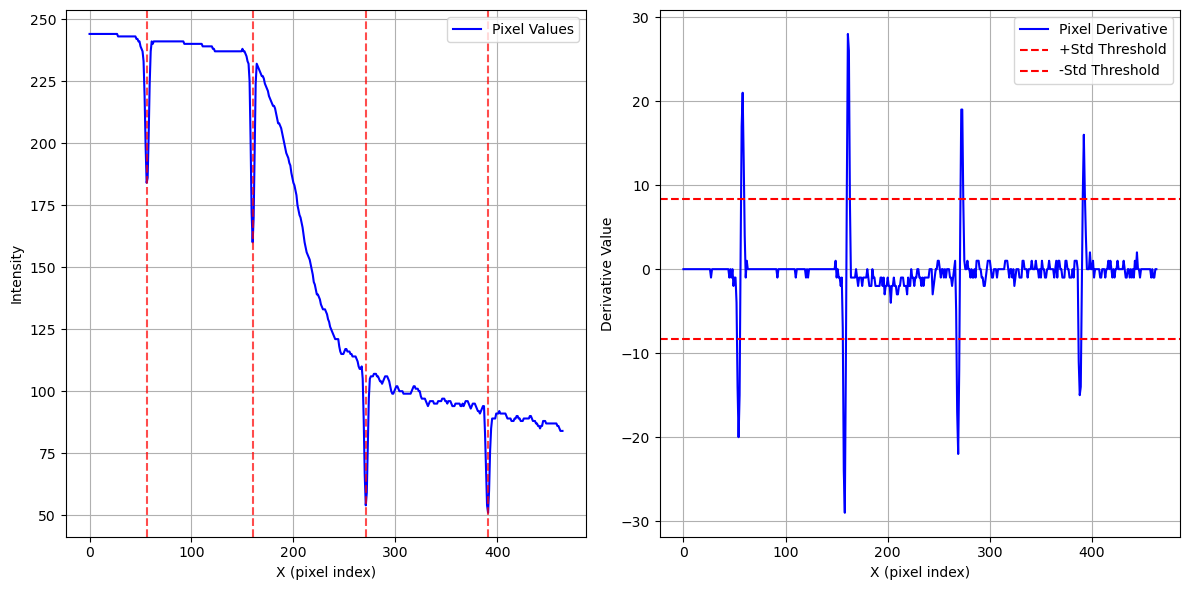

구간별 최소 인덱스: [np.int64(56), np.int64(160), np.int64(271), np.int64(391)]
marks: [np.int64(56), np.int64(160), np.int64(271), np.int64(391)]
mark cropped image shape: (482, 465)


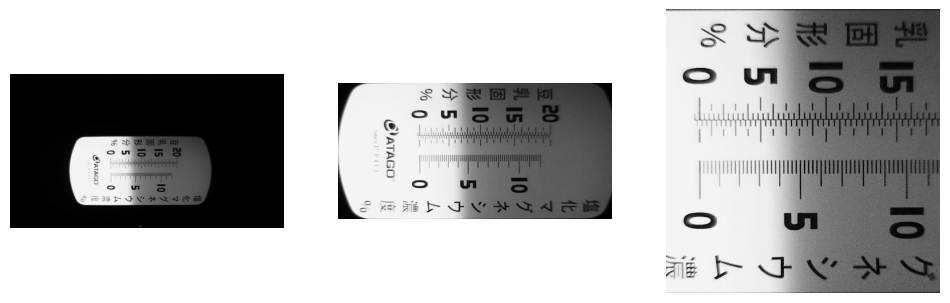

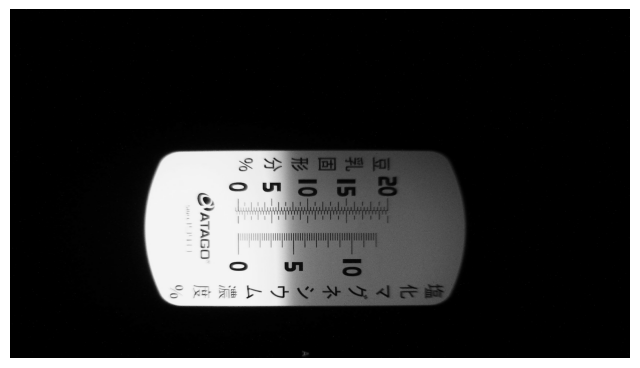

In [4]:
image_path = "images/real_test2.jpg"

img = cv2.imread(image_path)
if img.shape[0] > img.shape[1]:
    img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
image = cv2.resize(img.copy(), (1920, 1080))
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print(img.shape, image.shape)

# hough_line_demo(image)

average_angle, rotated_img = rotate_image(gray_image)
line_results, line_cropped_image = find_edges_line(rotated_img, 30000, 20000)
print("line cropped image shape:", line_cropped_image.shape)

left_crop_ratio = 0.24
right_crop_ratio = 0.72
analysis_image = line_cropped_image[:, int(line_cropped_image.shape[1]*left_crop_ratio):int(line_cropped_image.shape[1]*right_crop_ratio)]

sigma = 24
analysis_graph, width, min_index = analyze_analyze(analysis_image, sigma)

marks, pixel_values = crop_zero2fifth(analysis_image, min_index)
print("mark cropped image shape:", analysis_image.shape)
# cv2.imshow("analysis_image", analysis_image)

# # analysis_graph, width, min_index = analyze_image(analysis_image)
# predict_value, sorted_marks = get_prediction(marks, min_index)
# print("predict_value:", predict_value)
# analysis_image_color = cv2.cvtColor(analysis_image, cv2.COLOR_GRAY2BGR)
# cv2.line(analysis_image_color, (min_index, 0), (min_index, analysis_image_color.shape[0]), (0, 0, 255), 2)
# # 5 line draw
# for sorted_mark in sorted_marks:
#     cv2.line(analysis_image_color, (sorted_mark[1], 0), (sorted_mark[1], analysis_image_color.shape[0]), (0, 0, 0), 2)
# # cv2.imshow("analysis_image_color", analysis_image_color)

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(gray_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(line_cropped_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(analysis_image, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(gray_image, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 3, 1)
# plt.imshow(cv2.cvtColor(analysis_graph, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# plt.subplot(1, 3, 2)
# plt.imshow(cv2.cvtColor(analysis_image_color, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# plt.subplot(1, 3, 3)
# plt.imshow(cv2.cvtColor(line_cropped_image, cv2.COLOR_BGR2RGB))
# plt.axis('off')

# plt.tight_layout()
# plt.show()